
 Cleaned Dataset:

        Date Product Region    Sales
0 2025-08-01  Laptop  North  50000.0
1 2025-08-02   Phone  South  30000.0
2 2025-08-03  Laptop   East  33750.0
3 2025-08-04  Tablet   West  20000.0
4 2025-08-05   Phone  North  35000.0

 Total Sales per Product:

Product
Laptop    83750.0
Phone     65000.0
Tablet    20000.0
Name: Sales, dtype: float64

 Region-wise Sales:

Region
East     33750.0
North    85000.0
South    30000.0
West     20000.0
Name: Sales, dtype: float64


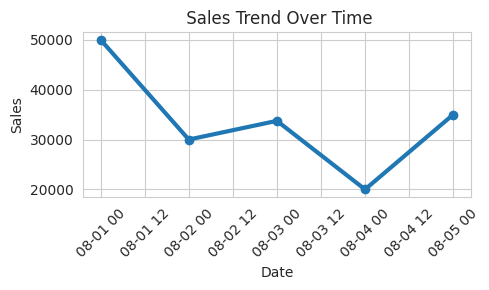

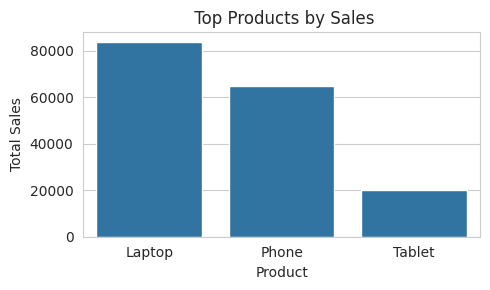


 Key Insights:
 Best Performing Product: Laptop
 Best Performing Region: North
 Average Sales: 33750.00
 Total Revenue: 168750.00

 Sales Growth (%):
0          NaN
1   -40.000000
2    12.500000
3   -40.740741
4    75.000000
Name: Sales, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Date": [
        "2025-08-01",
        "2025-08-02",
        "2025-08-03",
        "2025-08-04",
        "2025-08-05"
    ],
    "Product": [
        "Laptop",
        "Phone",
        "Laptop",
        "Tablet",
        "Phone"
    ],
    "Region": [
        "North",
        "South",
        "East",
        "West",
        "North"
    ],
    "Sales": [
        50000,
        30000,
        None,
        20000,
        35000
    ]
}

df = pd.DataFrame(data)
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())
df["Date"] = pd.to_datetime(df["Date"])

print("\n Cleaned Dataset:\n")
print(df)
product_sales = df.groupby("Product")["Sales"].sum()
region_sales = df.groupby("Region")["Sales"].sum()

print("\n Total Sales per Product:\n")
print(product_sales)

print("\n Region-wise Sales:\n")
print(region_sales)

sns.set_style("whitegrid")

plt.figure(figsize=(5, 3))

plt.plot(
    df["Date"],
    df["Sales"],
    marker='o',
    linewidth=3
)

plt.title(" Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_trend_chart.png")
plt.show()
plt.figure(figsize=(5, 3))

sns.barplot(
    x=product_sales.index,
    y=product_sales.values
)

plt.title(" Top Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("top_products_chart.png")
plt.show()

best_product = product_sales.idxmax()
best_region = region_sales.idxmax()

print("\n Key Insights:")
print(f" Best Performing Product: {best_product}")
print(f" Best Performing Region: {best_region}")
print(f" Average Sales: {df['Sales'].mean():.2f}")
print(f" Total Revenue: {df['Sales'].sum():.2f}")

sales_growth = df["Sales"].pct_change() * 100

print("\n Sales Growth (%):")
print(sales_growth)